# PSMILES

In [1]:
!pip install 'psmiles[polyBERT,mordred]@git+https://github.com/Ramprasad-Group/psmiles.git'

  Cloning https://github.com/Ramprasad-Group/psmiles.git to /tmp/pip-install-_r1rirvl/psmiles_07232bd01bd8458882c94315aeccb6ef
  Running command git clone --filter=blob:none --quiet https://github.com/Ramprasad-Group/psmiles.git /tmp/pip-install-_r1rirvl/psmiles_07232bd01bd8458882c94315aeccb6ef
  Resolved https://github.com/Ramprasad-Group/psmiles.git to commit 806b8dacc3c7d801bcfad74ff505b3c4b23db912
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Ramprasad-Group/canonicalize_psmiles.git to /tmp/pip-install-_r1rirvl/canonicalize-psmiles_e18207360e944524a314b77d059c5be1
  Running command git clone --filter=blob:none --quiet https://github.com/Ramprasad-Group/canonicalize_psmiles.git /tmp/pip-install-_r1rirvl/canonicalize-psmiles_e18207360e944524a314b77d059c5be1
  Resolved https://github.com/Ramprasad-Group/canonicalize_psmiles.git to commit 729dfd20b0e909df7cb245ffbfa5ab2

[*]CC(c1ccccc1)[*]


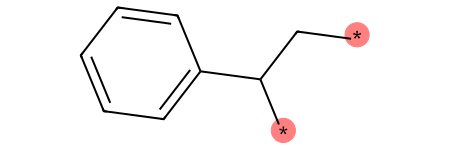

In [2]:
from psmiles import PolymerSmiles as PS
ps = PS('[*]CC(c1ccccc1)[*]' )
ps

[*]CC([*])c1ccccc1


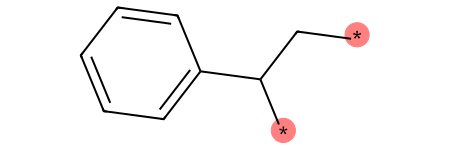

In [3]:
# Canonicalize the PSMILES string.
ps.canonicalize

In [4]:
# Save the figure to disk. Default name to PSMILES string.
ps.canonicalize.savefig()

C(c1ccccc1)(C[*])[*]


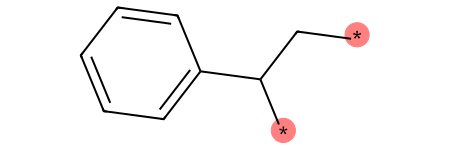

C(C(c1ccccc1)[*])[*]


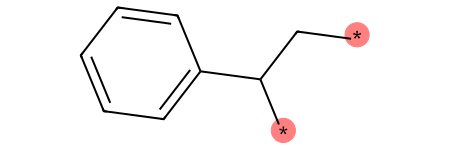

[*]C(C[*])c1ccccc1


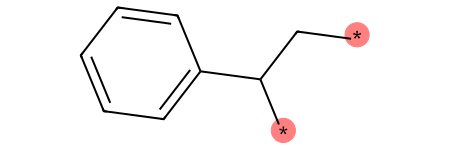

In [5]:
# Randomize the PSMILES string (chemistry is preserved)
_ = [display(ps.randomize) for _ in range(3)]

[*]CC([*])c1ccccc1


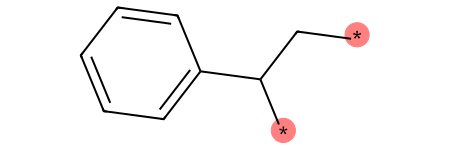

[*]CC([*])c1ccccc1


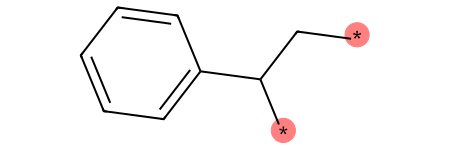

[*]CC([*])c1ccccc1


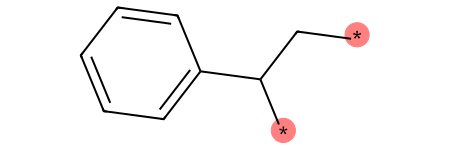

In [6]:
# First randomize then canonicalize the PSMILES strings. The PSMILES strings are the same.
pss = [ps.randomize.canonicalize for _ in range(3)]
[display(_ps) for _ps in pss]
assert len(set([str(_ps) for _ps in pss])) == 1

[*]C(CCC([*])c1ccccc1)c1ccccc1


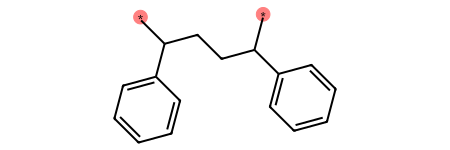

In [7]:
# Get the dimer from the monomer.
# Connect to first star
ps.dimer(0)

[*]CC(CC([*])c1ccccc1)c1ccccc1


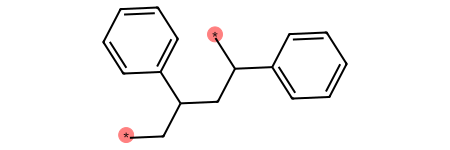

In [8]:
# Connect to second star
ps.dimer(1)

### Fingerprints for PSMILES strings

In [9]:
# CI fingerprint
ps.fingerprint('ci')

array([0, 1, 0, ..., 0, 0, 0])

In [10]:
# Mordred fingerprint
# print only the first 10 fingerprints
{k:v for k,v in [x for x in ps.fingerprint('mordred').items()][:10]}


/usr/local/lib/python3.12/dist-packages/mordred/_base/pandas_module.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  t[t.applymap(is_missing)] = value
/usr/local/lib/python3.12/dist-packages/mordred/_base/pandas_module.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  t[t.applymap(is_missing)] = value


{'ABC': nan,
 'ABCGG': nan,
 'nAcid': 0,
 'nBase': 0,
 'SpAbs_A': 10.919243957164399,
 'SpMax_A': 0.0882861506245467,
 'SpDiam_A': 0.17657230124909162,
 'SpAD_A': 10.919243957164399,
 'SpMAD_A': 0.0351900432420158,
 'LogEE_A': 0.6056354340913521}

In [11]:
ps.fingerprint('rdkit')

array([0, 0, 0, ..., 0, 0, 0])

In [12]:
# polyBERT fingerprint.
# polyBERT is a chemical language model that has learned to predict PSMILES string fingerprints.
# polyBERT is super fast
ps.fingerprint('polyBERT')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/84.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

array([ 3.50811630e-01,  1.14510246e-01,  3.86458427e-01, -5.47734976e-01,
       -1.64251506e+00, -1.20370358e-01,  1.00393069e+00, -3.96532193e-02,
       -2.62746420e-02,  4.91385072e-01, -3.88579458e-01, -9.19213295e-02,
        6.85911834e-01, -1.63276243e+00, -1.48769486e+00, -8.93421710e-01,
       -9.03815329e-01, -1.25334418e+00, -7.01706767e-01, -4.42329735e-01,
        9.31518734e-01,  6.43249676e-02,  6.18372500e-01,  3.25154692e-01,
       -7.15663612e-01,  8.33098352e-01,  2.78026628e+00,  7.38025010e-02,
       -1.15337014e+00, -8.77115279e-02,  4.78095382e-01, -1.24472129e+00,
        2.36280754e-01, -7.10529625e-01,  1.38347065e+00,  3.42699856e-01,
       -3.61699611e-01,  3.40443999e-02,  1.38261557e-01,  2.92336196e-01,
       -1.81008458e-01,  1.50301531e-01,  6.96576536e-01,  1.06370616e+00,
        6.04684412e-01,  9.43712234e-01,  1.44894171e+00, -1.37666285e-01,
        1.19438052e+00,  1.00399986e-01, -2.21899986e-01,  2.37761050e-01,
       -2.06672549e-01, -

### Canonicalize PSMILES

set `logging.getLogger().setLevel(logging.DEBUG)` for verbose mode


In [13]:
# add draw options
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.drawOptions.addBondIndices= False
IPythonConsole.drawOptions.minFontSize = 16
IPythonConsole.molSize = (600, 200)   # Change image size
IPythonConsole.ipython_useSVG = True  # Change output to SVG

[*]NC(C)CC([*])=O


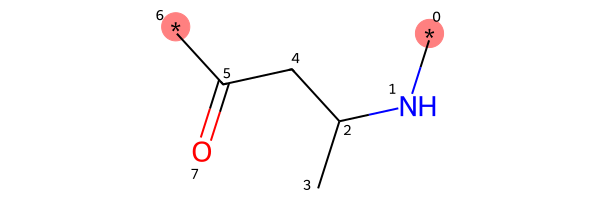

[*]CC(=O)NC([*])C


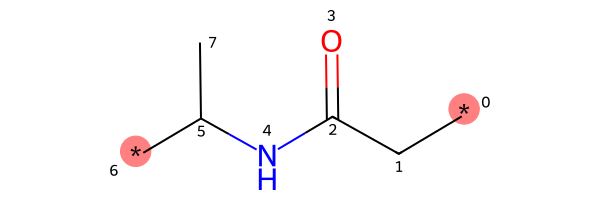

In [14]:
import logging
# The INFO level does not give any additional information
logging.getLogger().setLevel(logging.INFO)
sm = '[*]NC(C)CC([*])=O'
display(PS(sm))
display(PS(sm).canonicalize)

[*]NC(C)CC([*])=O


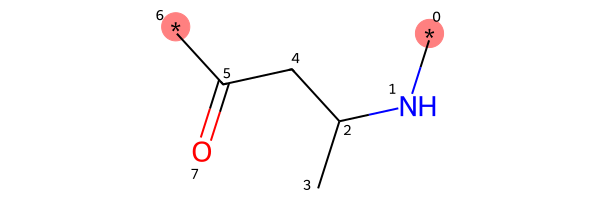

DEBUG:root:(1) Set labels and get connection dict 
 {'atom_rings': (),
 'bond_rings': (),
 'index': [0, 1, 2, 3, 4, 5, 6, 7],
 'neighbor': {'atom_type': [['N'], ['C']],
              'bond_type': [[rdkit.Chem.rdchem.BondType.SINGLE],
                            [rdkit.Chem.rdchem.BondType.SINGLE]],
              'index': [[1], [5]],
              'path': (1, 2, 4, 5)},
 'star': {'atom_type': ['*', '*'], 'bond_type': None, 'index': [0, 6]},
 'stereo': [],
 'symbols': ['*', 'N', 'C', 'C', 'C', 'C', '*', 'O']}


SMILES: *NC(C)CC(*)=O |$;N1;;;;N2;;$,atomProp:0.dummyLabel.*:6.dummyLabel.*|


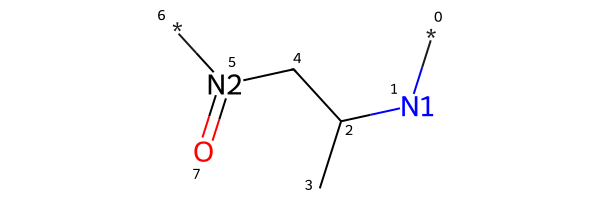

DEBUG:root:(2) Add bond between neighbors [[1], [5]]; bond type SINGLE SINGLE 


SMILES: *N1C(C)CC1(*)=O |$;N1;;;;N2;;$,atomProp:0.dummyLabel.*:6.dummyLabel.*|


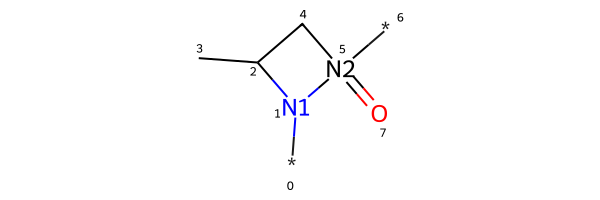

DEBUG:root:(3) Remove stars and bonds


SMILES: CC1CC(=O)N1 |$;;;N2;;N1$|


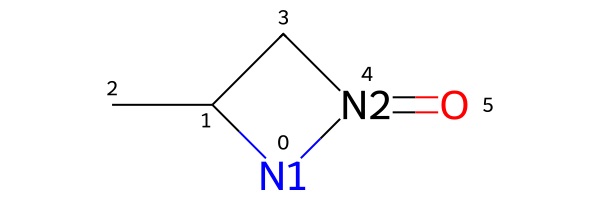

DEBUG:root:(4) Canonicalize


SMILES: CC1CC(=O)N1 |$;;;N2;;N1$|


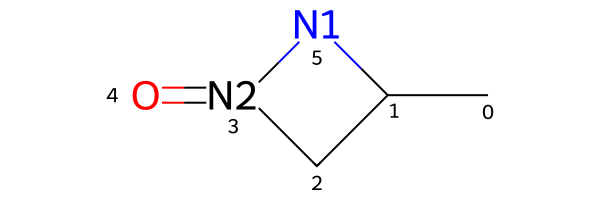

DEBUG:root:Found 1 rings that contain N1 and N2 and have length 4
DEBUG:root:Possible rings to break: [(1, 5, 3, 2)]
DEBUG:root:Searching in ring (sorted index): [1, 2, 3, 5]
DEBUG:root:Index 1 and 2 are in ring and connected with bond 1. Bond 1 is not in other rings. Break.
DEBUG:root:(5) Break bond at atom idx 1 and 2. Bond type was SINGLE


SMILES: CCNC(C)=O |$;;N1;N2;;$|


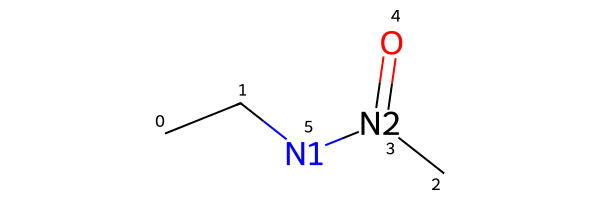

DEBUG:root:(6) Add stars at index 1 and 2 with bond type SINGLE. Renumber atoms.


SMILES: *CC(=O)NC(*)C |atomProp:0.dummyLabel.*:6.dummyLabel.*|


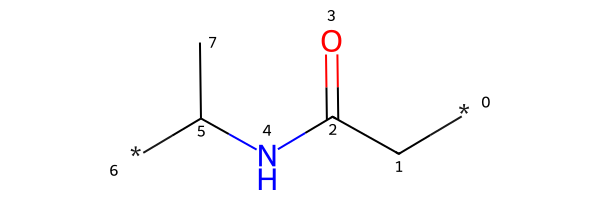

[*]CC(=O)NC([*])C


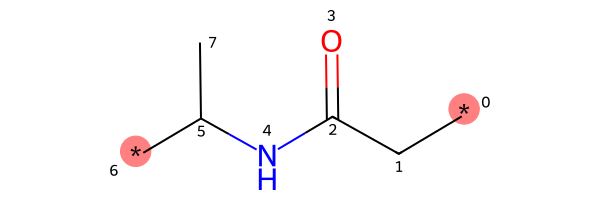

In [15]:
import logging
# The DEBUG level visualizes the canonicalization process
logging.getLogger().setLevel(logging.DEBUG)
sm = '[*]NC(C)CC([*])=O'
display(PS(sm))
display(PS(sm).canonicalize)

### Inchi string and inchi key of PSMILES string

In [16]:
logging.getLogger().setLevel(logging.INFO)
ps.inchi

[03:14:05] WARNING: Omitted undefined stereo



'InChI=1S/C8H8At2/c9-6-8(10)7-4-2-1-3-5-7/h1-5,8H,6H2'

In [17]:
ps.inchi_key

'PYOVDMHONBXEFX-UHFFFAOYSA-N'

###  Alternating copolymers from two PSMILES strings
The second argument of the function alternating_copolymer specifies which how the *s are connected

[*]CC(C)(CCO[*])C(=O)Oc1cccc(C)c1C


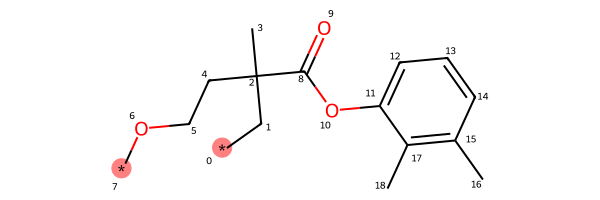

In [18]:
ps1 = PS('C(C([*])(C([*]))C)(=O)OC1=C(C(=CC=C1)C)C')
ps2 = PS('[*]CCO[*]')
ps1.alternating_copolymer(ps2, [0,0])

[*]CCOC(C)(C[*])C(=O)Oc1cccc(C)c1C


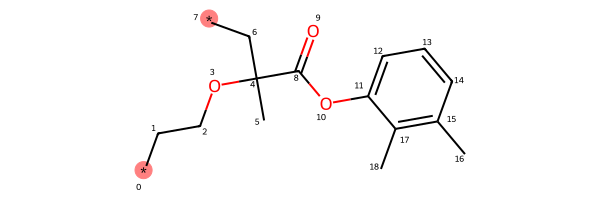

In [19]:
ps1.alternating_copolymer(ps2, [0,1])

[*]OCCCC([*])(C)C(=O)Oc1cccc(C)c1C


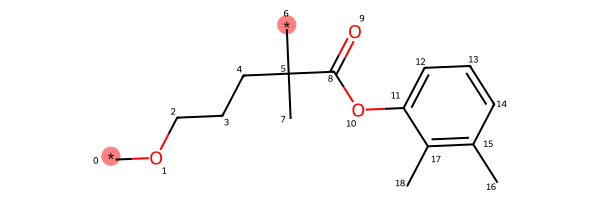

In [20]:
ps1.alternating_copolymer(ps2, [1,0])

[*]CCOCC([*])(C)C(=O)Oc1cccc(C)c1C


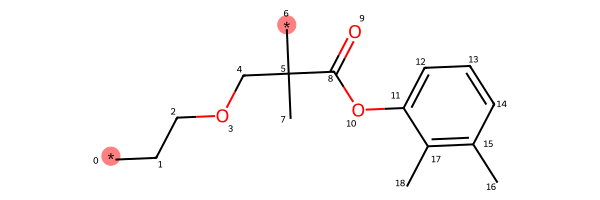

In [21]:
ps1.alternating_copolymer(ps2, [1,1])

COC(C([*])(C[*])C)=O


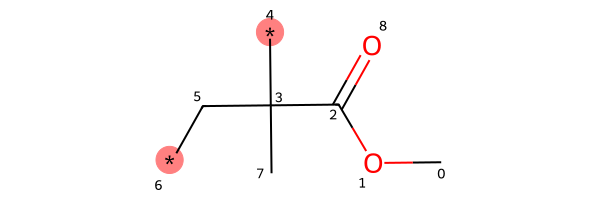

In [24]:
ps = PS('COC(C([*])(C[*])C)=O')
ps

CCC(C[*])(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C[*])(C(=O)OC)C


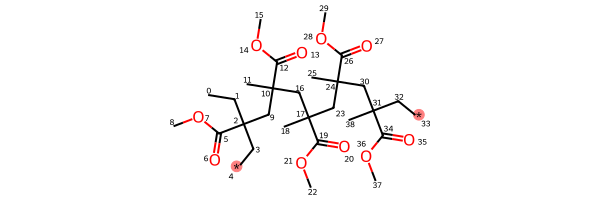

In [26]:
ps = PS('CCC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C)(C(=O)OC)CC(C[*])(C(=O)OC)C')
ps